In [1]:
import numpy as np
import polars as pl
import scipy.stats as ss
import seaborn as sns

In [2]:
path = "/Users/zipp/Desktop/programming/ml-training/data2/internal/v6/*.xlsx"
df = pl.read_excel(path, sheet_name="Tabelle1")
print(df.shape)
df = (
    df.rename(
        {
            "Buchungskreis (SEM)": "company_code",
            "Gruppenkonto": "account",
            "Partnerbuchungskreis (SEM Schwarz)": "partner_company_code",
            "EUR": "value",
            "GJ-Periode": "period",
        }
    )
    .filter(pl.col("partner_company_code") != pl.lit("#"))
    .group_by(["company_code", "account", "period"])
    .agg(pl.col("value").sum())
    .sort(by=["company_code", "period"])
)
print(df.shape)
df.group_by(["company_code", "account"]).agg(pl.len()).sort(by="len", descending=True)

(509938, 5)
(63824, 4)


company_code,account,len
str,str,u32
"""0658""","""301K866225""",94
"""0658""","""315K420005""",91
"""0658""","""3150491005""",90
"""0658""","""315K498405""",89
"""0658""","""315K498413""",89
…,…,…
"""0993""","""315K498417""",1
"""1511""","""3150237115""",1
"""1871""","""3150498600""",1


In [3]:
X_df = df.filter(
    (pl.col("company_code") == pl.lit("0658"))
    & (pl.col("account") == pl.lit("301K866225"))
    & ~(pl.col("period").str.starts_with("13/"))
)
X_df.head()

company_code,account,period,value
str,str,str,f64
"""0658""","""301K866225""","""01/2018""",1472098.9
"""0658""","""301K866225""","""01/2019""",1.1597e6
"""0658""","""301K866225""","""01/2020""",1298470.5
"""0658""","""301K866225""","""01/2021""",1.1403e6
"""0658""","""301K866225""","""01/2022""",1.1484e6


In [4]:
X_df.describe()

statistic,company_code,account,period,value
str,str,str,str,f64
"""count""","""87""","""87""","""87""",87.0
"""null_count""","""0""","""0""","""0""",0.0
"""mean""",null,null,null,1.1058e6
"""std""",null,null,null,550744.037642
"""min""","""0658""","""301K866225""","""01/2018""",-231320.95
"""25%""",null,null,null,720317.75
"""50%""",null,null,null,937611.6
"""75%""",null,null,null,1.4137e6
"""max""","""0658""","""301K866225""","""12/2024""",3.1758e6


<Axes: >

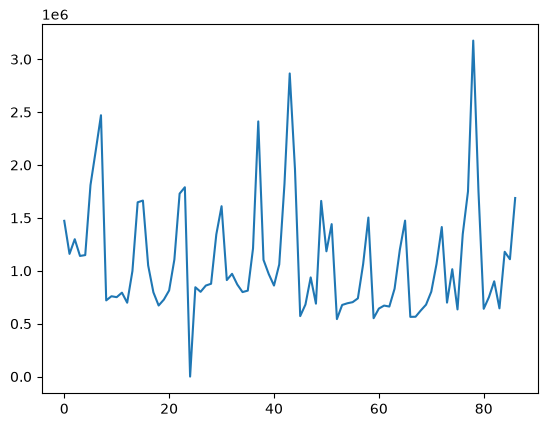

In [5]:
X = X_df.get_column("value").to_numpy().copy()
X[np.where(X < 0)] = 0.01
X_log_diff = np.diff(np.log(X), 1)
ss.normaltest(X_log_diff)
# sns.histplot(x=X, bins=20, kde=True)
# sns.histplot(x=X_log_diff, bins=50, kde=True)
sns.lineplot(X)

In [6]:
season = (
    pl.when(pl.col("month").is_in([3, 4, 5]))
    .then(pl.lit("spring"))
    .when(pl.col("month").is_in([6, 7, 8]))
    .then(pl.lit("summer"))
    .when(pl.col("month").is_in([9, 10, 11]))
    .then(pl.lit("autumn"))
    .otherwise(pl.lit("winter"))
    .cast(
        pl.Enum(
            (
                "spring",
                "summer",
                "autumn",
                "winter",
            )
        )
    )
)
feature_df = (
    X_df.drop(["company_code", "account"])
    .with_columns(
        pl.col("period").str.to_date(r"%m/%Y").dt.year().alias("year"),
        ((pl.col("period").str.to_date(r"%m/%Y").dt.month() + 3) % 12).alias("month"),
    )
    .with_columns(season.alias("season"))
    .drop("period")
)
feature_df.describe()
feature_df.to_numpy()

array([[1472098.9, 2018, 4, 'spring'],
       [1159710.65, 2019, 4, 'spring'],
       [1298470.5, 2020, 4, 'spring'],
       [1140258.3699999999, 2021, 4, 'spring'],
       [1148417.9000000001, 2022, 4, 'spring'],
       [1809852.99, 2023, 4, 'spring'],
       [2135010.56, 2024, 4, 'spring'],
       [2470296.23, 2025, 4, 'spring'],
       [720317.75, 2018, 5, 'spring'],
       [759425.2000000001, 2019, 5, 'spring'],
       [750665.3, 2020, 5, 'spring'],
       [793266.24, 2021, 5, 'spring'],
       [698277.2, 2022, 5, 'spring'],
       [997825.03, 2023, 5, 'spring'],
       [1647570.77, 2024, 5, 'spring'],
       [1663713.49, 2025, 5, 'spring'],
       [1050893.05, 2018, 6, 'summer'],
       [796207.8, 2019, 6, 'summer'],
       [671890.45, 2020, 6, 'summer'],
       [727974.73, 2021, 6, 'summer'],
       [814093.19, 2022, 6, 'summer'],
       [1106225.89, 2023, 6, 'summer'],
       [1729232.82, 2024, 6, 'summer'],
       [1789686.1400000001, 2025, 6, 'summer'],
       [-231320.95, 201

In [7]:
import xgboost as xgb
from sklearn.metrics import mean_absolute_percentage_error

train_len = 70
X = feature_df.drop("value")
y = feature_df.get_column("value")
X_train = X[:70, :]
x_test = X[70:, :]
y_train = y[:70]
y_test = y[70:]
model = xgb.XGBRegressor(
    enable_categorical=True,
    max_depth=2,  # Keep the trees extremely shallow
    n_estimators=15,  # Stop training after just a few trees
    learning_rate=0.1,
).fit(X_train, y_train)
X_train.shape, y_train.shape
preds = model.predict(x_test)
mean_absolute_percentage_error(y_test, preds)

0.25962218003769677

In [8]:
X_val = y_train.mean()
mean_absolute_percentage_error(y_test, np.array([X_val] * y_test.len()))

0.35299326211627186

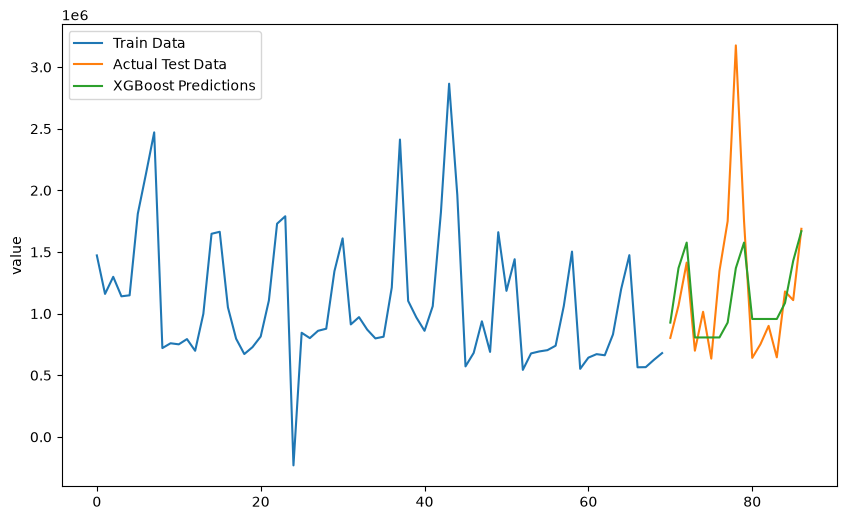

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns

# 1. Create matching x-axes for each specific segment
# Train starts at 0 and goes to train_len
x_train_axis = np.arange(len(y_train))

# Test and Predictions start right after Train ends
x_test_axis = np.arange(len(y_train), len(y_train) + len(y_test))

# 2. Plot them
plt.figure(figsize=(10, 6))

sns.lineplot(x=x_train_axis, y=y_train, label="Train Data")
sns.lineplot(x=x_test_axis, y=y_test, label="Actual Test Data")
sns.lineplot(x=x_test_axis, y=preds, label="XGBoost Predictions")

plt.legend()
plt.show()

<Axes: >

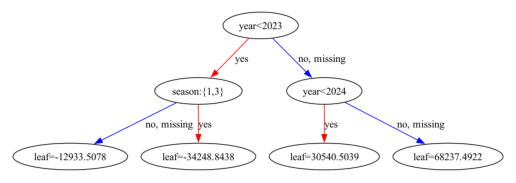

In [10]:
xgb.plot_tree(model)